câu 1:

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.29MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 135kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.57MB/s]


tr_images & tr_targets
X - torch.Size([60000, 28, 28])
Y - torch.Size([60000])
Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK : 10 class Classification
UNIQUE CLASSES:
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


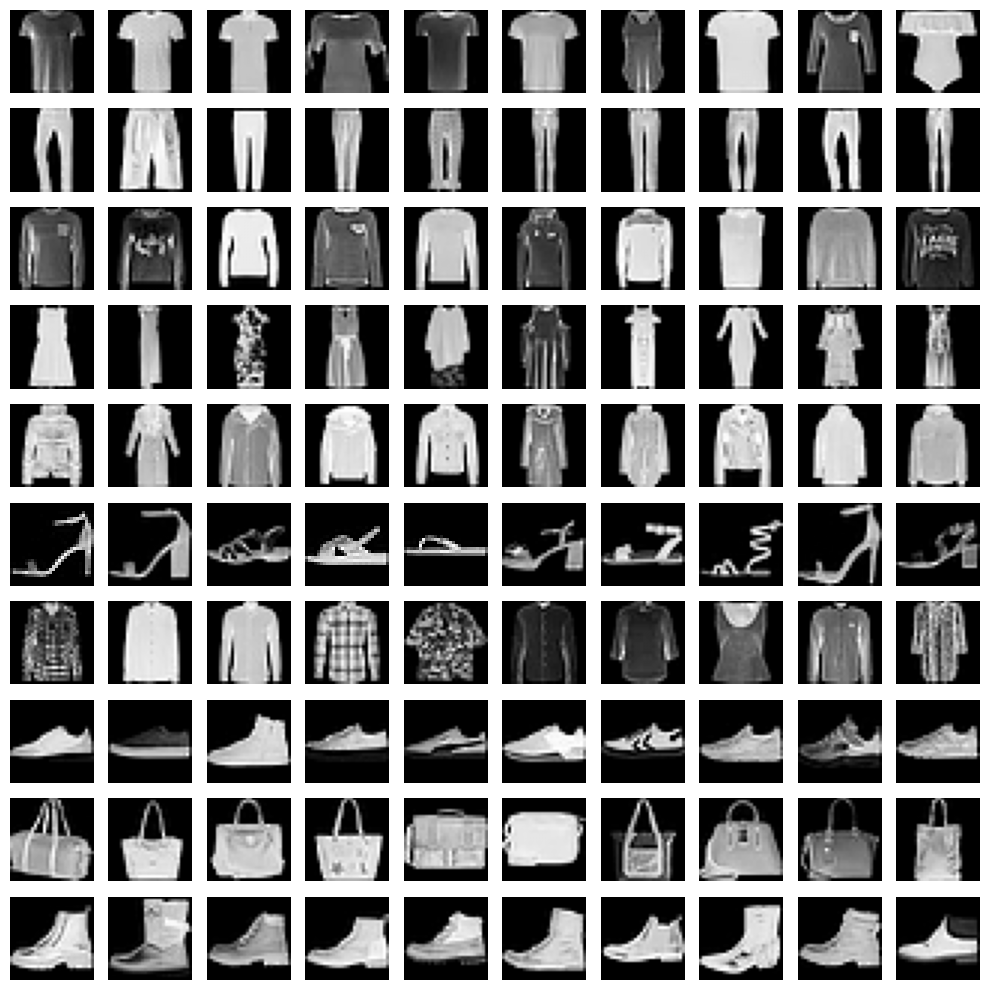

In [1]:
# Import thư viện
from torchvision import datasets
import torch
import matplotlib.pyplot as plt
import numpy as np

# Tải bộ dữ liệu FashionMNIST
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    root=data_folder,
    train=True,
    download=True
)

# Lấy dữ liệu ảnh và nhãn
tr_images = fmnist.data
tr_targets = fmnist.targets

# Kiểm tra dữ liệu
unique_values = tr_targets.unique()

print("tr_images & tr_targets")
print(f"X - {tr_images.shape}")
print(f"Y - {tr_targets.shape}")
print(f"Unique Values : {unique_values}")
print(f"TASK : {len(unique_values)} class Classification")
print("UNIQUE CLASSES:")
print(fmnist.classes)

# Hiển thị ảnh của 10 lớp
R, C = len(unique_values), 10

fig, ax = plt.subplots(R, C, figsize=(10, 10))

for label_class, plot_row in enumerate(ax):

    # Lấy các vị trí thuộc lớp hiện tại
    label_x_rows = np.where(tr_targets.numpy() == label_class)[0]

    for plot_cell in plot_row:

        plot_cell.grid(False)
        plot_cell.axis("off")

        # Chọn ngẫu nhiên một ảnh trong lớp
        ix = np.random.choice(label_x_rows)

        x = tr_images[ix]

        plot_cell.imshow(x, cmap="gray")

plt.tight_layout()
plt.show()

câu 2

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_12650/3977997873.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


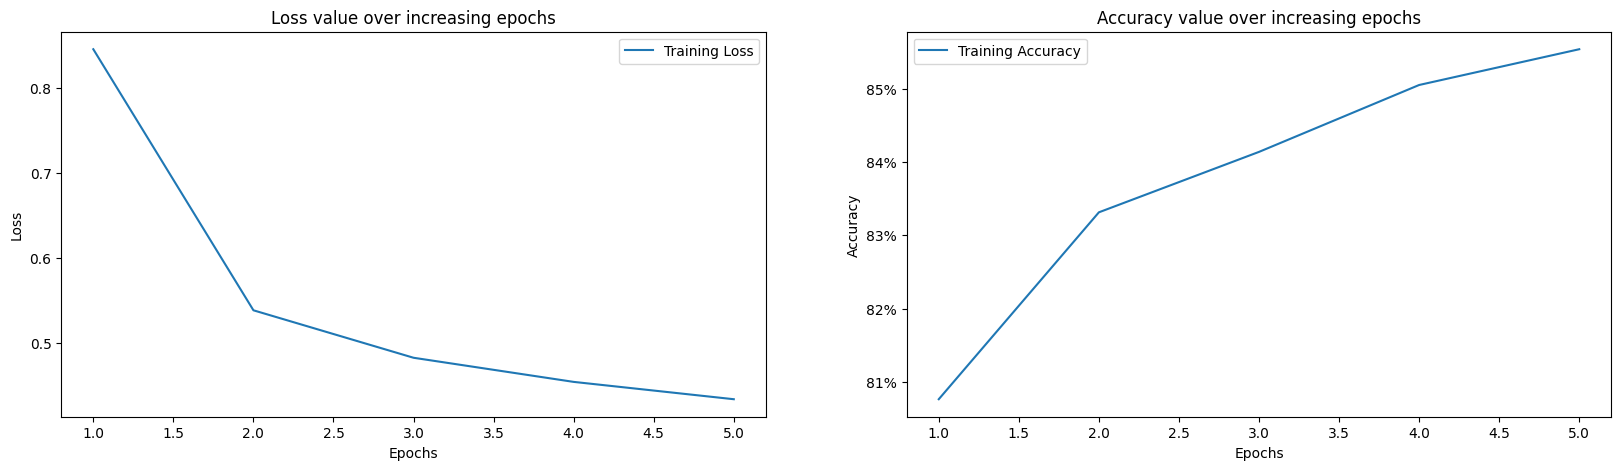

In [2]:
# Import thư viện
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import SGD

# Chọn thiết bị CPU/GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu FashionMNIST
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

# Tạo Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# Tạo DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

# Xây dựng mô hình
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

# Hàm huấn luyện 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Hàm tính độ chính xác
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Huấn luyện mô hình
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

losses = []
accuracies = []

for epoch in range(5):
    print("Epoch:", epoch + 1)

    epoch_losses = []
    epoch_accuracies = []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        batch_loss = train_batch(
            x, y,
            model,
            optimizer,
            loss_fn
        )

        epoch_losses.append(batch_loss)

    epoch_loss = np.mean(epoch_losses)

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        is_correct = accuracy(x, y, model)

        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

# Vẽ biểu đồ Loss
epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(122)
plt.title("Accuracy value over increasing epochs")
plt.plot(epochs, accuracies, label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(
    ["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()]
)
plt.legend()

plt.show()

câu 3

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_12650/3617917350.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


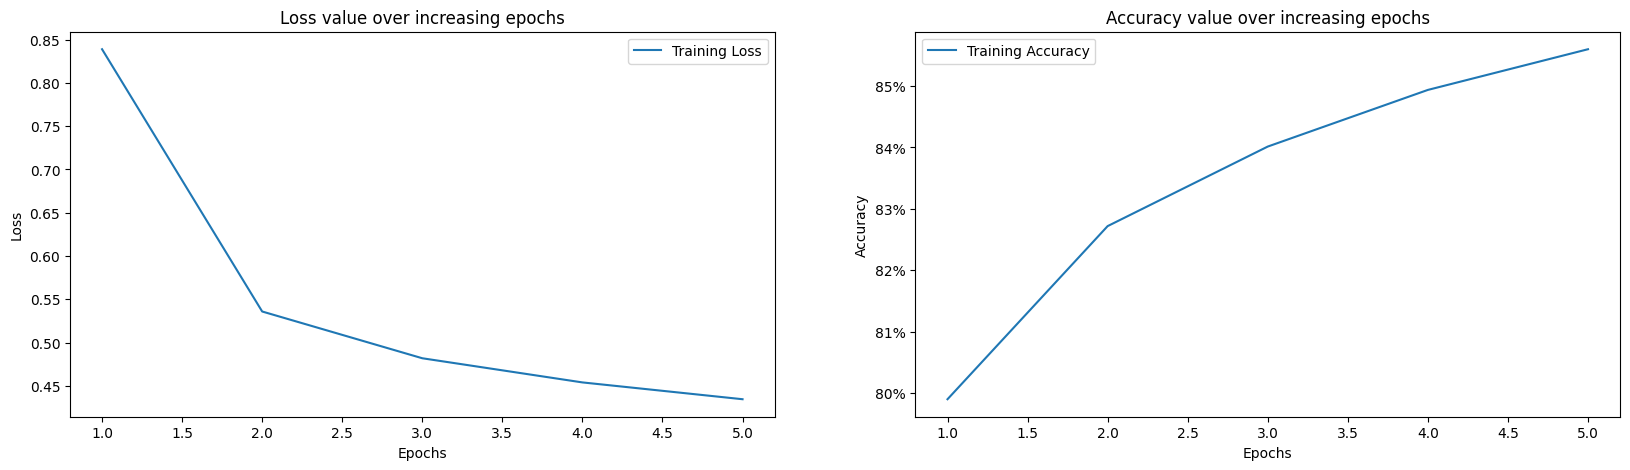

In [3]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import SGD
import numpy as np
import matplotlib.pyplot as plt

# Chọn CPU hoặc GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

# Tạo Dataset, chuẩn hóa ảnh về khoảng 0 đến 1
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# Tạo DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

# Tạo mô hình
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

# Huấn luyện 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Tính độ chính xác
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Huấn luyện mô hình
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

losses = []
accuracies = []

for epoch in range(5):
    print("Epoch:", epoch + 1)

    epoch_losses = []
    epoch_accuracies = []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        batch_loss = train_batch(
            x, y,
            model,
            optimizer,
            loss_fn
        )

        epoch_losses.append(batch_loss)

    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        is_correct = accuracy(x, y, model)

        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

# Vẽ biểu đồ
epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.title("Loss value over increasing epochs")
plt.plot(epochs, losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(122)
plt.title("Accuracy value over increasing epochs")
plt.plot(epochs, accuracies, label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(
    ["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()]
)
plt.legend()

plt.show()

câu 4

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_12650/1103614486.py:191: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


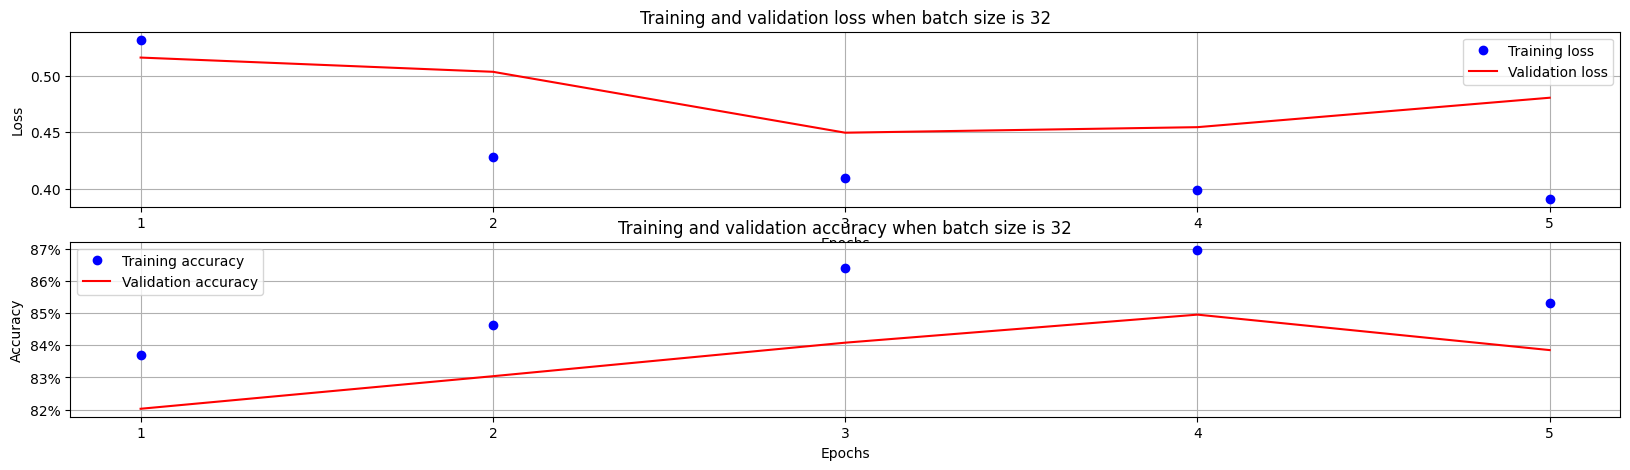

In [4]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Chọn CPU/GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu train
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

# Tải dữ liệu validation/test
val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# Tạo Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# Tạo DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl

# Tạo model
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

# Huấn luyện 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Tính accuracy
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Tính validation loss
@torch.no_grad()
def val_loss(x, y, model):
    model.eval()

    prediction = model(x)
    val_loss = loss_fn(prediction, y)

    return val_loss.item()

# Lấy dữ liệu và model
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Huấn luyện
for epoch in range(5):
    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    val_epoch_accuracies = []

    # Train
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        batch_loss = train_batch(
            x, y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    # Train accuracy
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Validation
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch

        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

        val_epoch_accuracies.extend(val_is_correct)

    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

# Vẽ biểu đồ
epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mtick.MultipleLocator(1))
plt.title("Training and validation loss when batch size is 32")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid("off")

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mtick.MultipleLocator(1))
plt.title("Training and validation accuracy when batch size is 32")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(
    ["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()]
)
plt.legend()
plt.grid("off")

plt.show()

câu 5

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_12650/3657106128.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


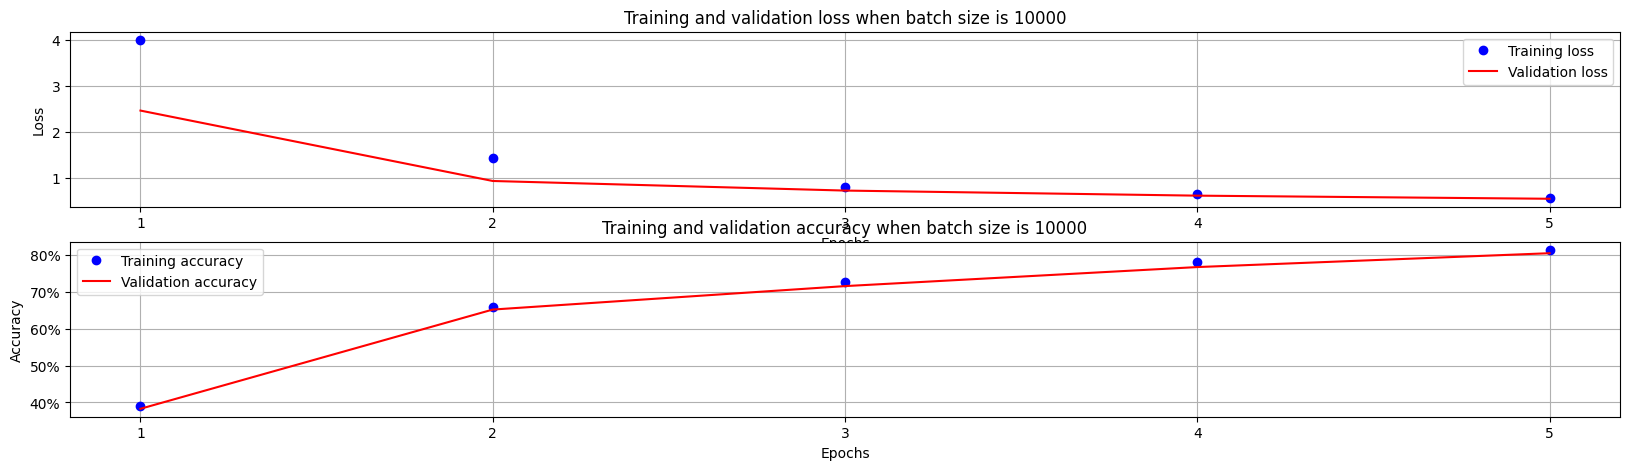

In [5]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"

data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        return self.x[ix].to(device), self.y[ix].to(device)

    def __len__(self):
        return len(self.x)

def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=10000, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model):
    model.eval()
    prediction = model(x)
    loss = loss_fn(prediction, y)
    return loss.item()

trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(5):
    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []
    val_epoch_accuracies = []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracies.extend(val_is_correct)

    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss when batch size is 10000")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid("off")

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy when batch size is 10000")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(
    ["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()]
)
plt.legend()
plt.grid("off")

plt.show()

câu 6

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10


/tmp/ipykernel_12650/878509738.py:278: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


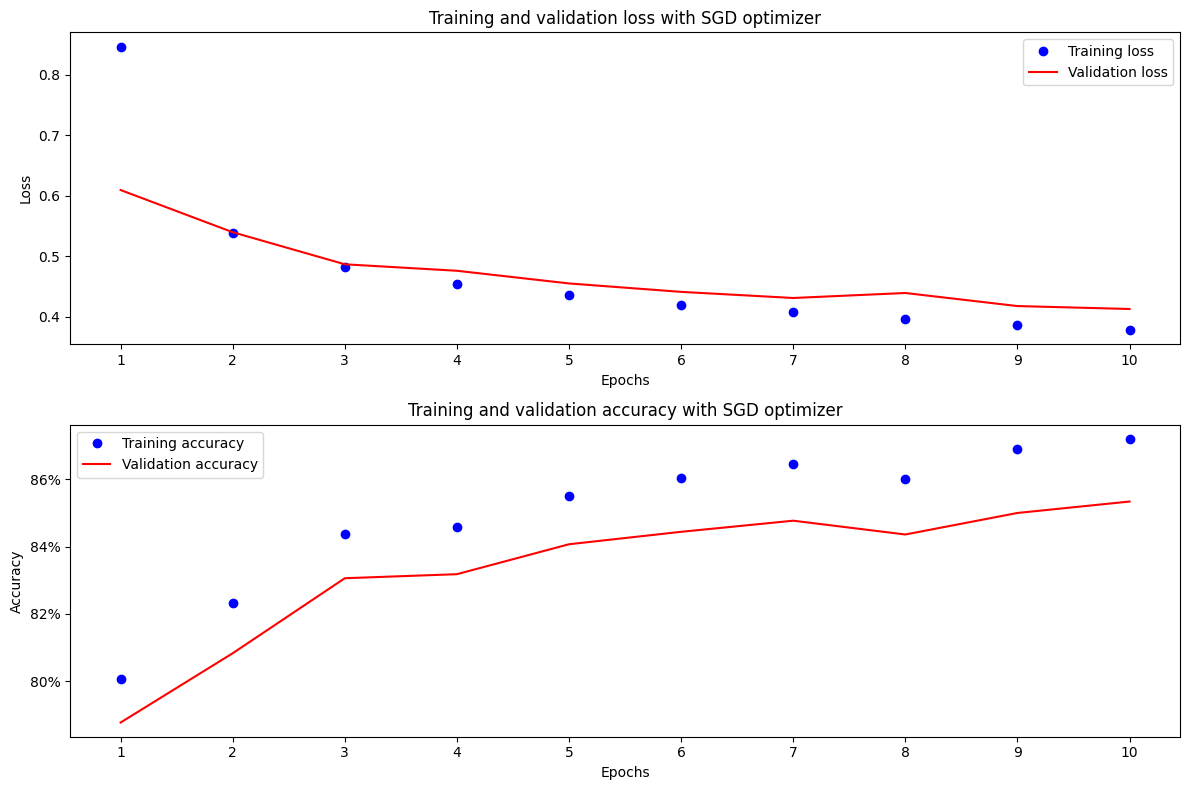

In [6]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import SGD
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chọn CPU/GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu train
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

# Tải dữ liệu validation
val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# Model + SGD Optimizer
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = SGD(
        model.parameters(),
        lr=1e-2
    )

    return model, loss_fn, optimizer

# Train 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)

    batch_loss = loss_fn(
        prediction,
        y
    )

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Accuracy
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Validation Loss
@torch.no_grad()
def val_loss(x, y, model):
    model.eval()

    prediction = model(x)

    loss = loss_fn(prediction, y)

    return loss.item()

# Lấy dữ liệu
trn_dl, val_dl = get_data()

# Khởi tạo model
model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Train 10 Epoch
for epoch in range(10):

    print(f"Epoch {epoch+1}")

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(
            x, y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    # Train Accuracy
    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(
            x, y,
            model
        )

        train_epoch_accuracies.extend(
            is_correct
        )

    train_epoch_accuracy = np.mean(
        train_epoch_accuracies
    )

    # Validation
    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(
            x, y,
            model
        )

        validation_loss = val_loss(
            x, y,
            model
        )

    val_epoch_accuracy = np.mean(
        val_is_correct
    )

    train_losses.append(
        train_epoch_loss
    )

    train_accuracies.append(
        train_epoch_accuracy
    )

    val_losses.append(
        validation_loss
    )

    val_accuracies.append(
        val_epoch_accuracy
    )

# Vẽ biểu đồ
epochs = np.arange(10) + 1

plt.figure(figsize=(12,8))

# Loss
plt.subplot(211)

plt.plot(
    epochs,
    train_losses,
    'bo',
    label='Training loss'
)

plt.plot(
    epochs,
    val_losses,
    'r',
    label='Validation loss'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation loss with SGD optimizer'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

# Accuracy
plt.subplot(212)

plt.plot(
    epochs,
    train_accuracies,
    'bo',
    label='Training accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    'r',
    label='Validation accuracy'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation accuracy with SGD optimizer'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    [
        '{:.0f}%'.format(x * 100)
        for x in plt.gca().get_yticks()
    ]
)

plt.legend()

plt.tight_layout()
plt.show()

câu 7

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10


/tmp/ipykernel_12650/3060139007.py:269: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


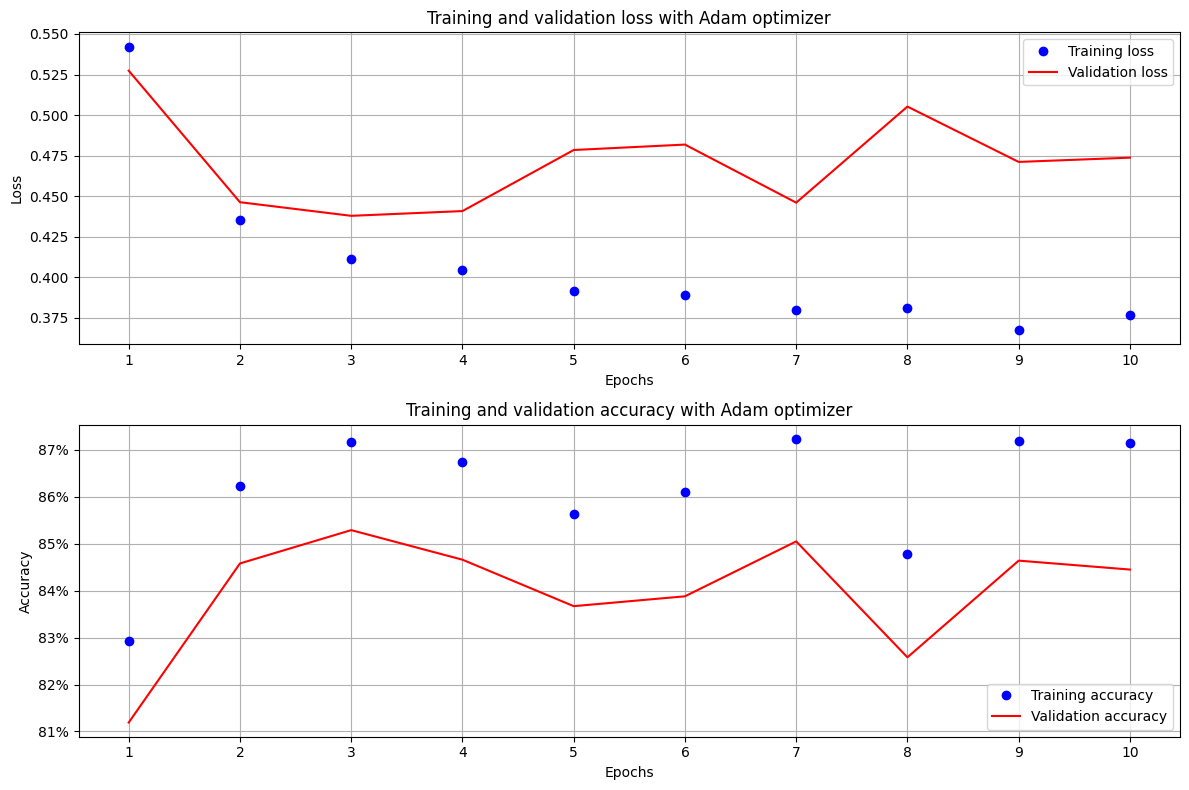

In [7]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chọn CPU hoặc GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu FashionMNIST
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# Tạo Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# Tạo DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# Tạo mô hình với Adam Optimizer
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(
        model.parameters(),
        lr=1e-2
    )

    return model, loss_fn, optimizer

# Huấn luyện 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)

    batch_loss = loss_fn(
        prediction,
        y
    )

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Tính độ chính xác
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Tính validation loss
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)

    loss = loss_fn(
        prediction,
        y
    )

    return loss.item()

# Lấy dữ liệu và mô hình
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Huấn luyện mô hình 10 epoch
for epoch in range(10):

    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train loss
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(
            x,
            y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    # Train accuracy
    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(
            x,
            y,
            model
        )

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Validation
    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(
            x,
            y,
            model
        )

        validation_loss = val_loss(
            x,
            y,
            model,
            loss_fn
        )

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

# Vẽ biểu đồ
epochs = np.arange(10) + 1

plt.figure(figsize=(12, 8))

plt.subplot(211)

plt.plot(
    epochs,
    train_losses,
    "bo",
    label="Training loss"
)

plt.plot(
    epochs,
    val_losses,
    "r",
    label="Validation loss"
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    "Training and validation loss with Adam optimizer"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid("off")

plt.subplot(212)

plt.plot(
    epochs,
    train_accuracies,
    "bo",
    label="Training accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    "r",
    label="Validation accuracy"
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    "Training and validation accuracy with Adam optimizer"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.gca().set_yticklabels(
    [
        "{:.0f}%".format(x * 100)
        for x in plt.gca().get_yticks()
    ]
)

plt.legend()
plt.grid("off")

plt.tight_layout()
plt.show()

câu 8

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5


/tmp/ipykernel_12650/3996398300.py:332: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


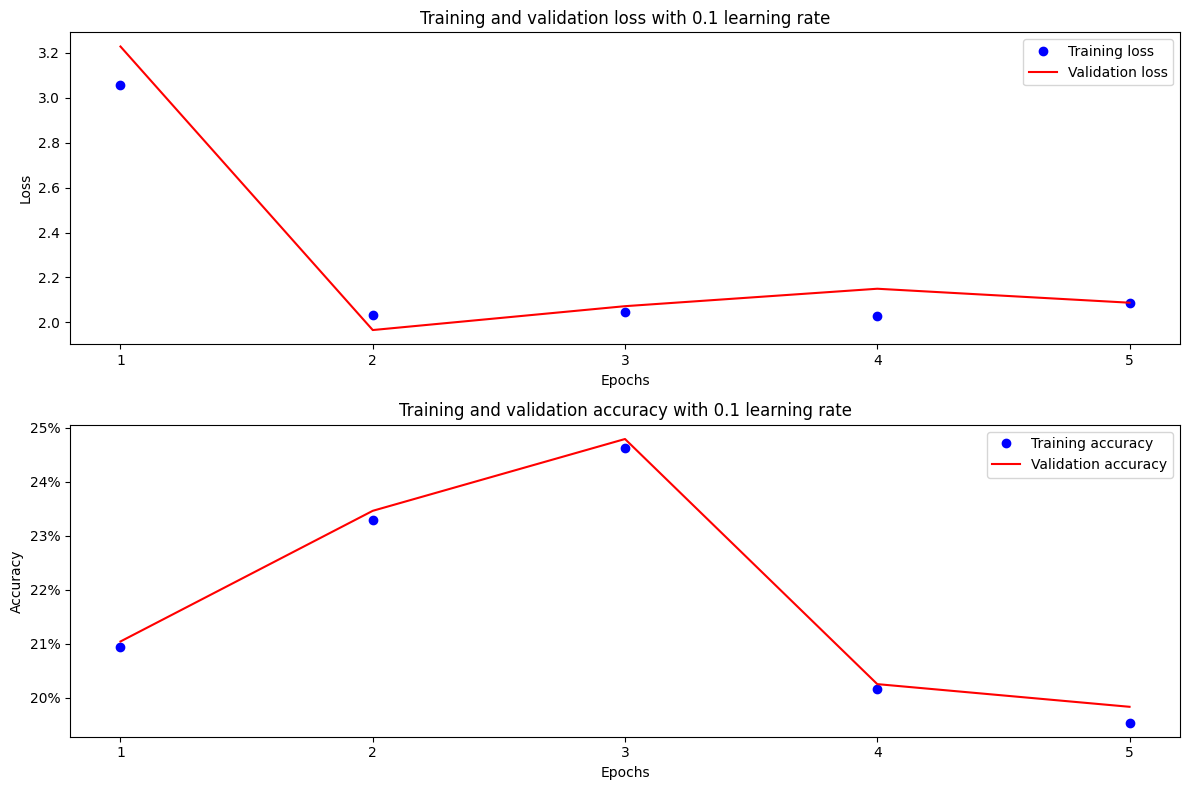

In [8]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chọn CPU hoặc GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# ======================
# TẢI DỮ LIỆU
# ======================

data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# ======================
# DATASET
# ======================

class FMNISTDataset(Dataset):
    def __init__(self, x, y):

        x = x.float() / 255
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):

        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# ======================
# DATALOADER
# ======================

def get_data():

    train = FMNISTDataset(
        tr_images,
        tr_targets
    )

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    val = FMNISTDataset(
        val_images,
        val_targets
    )

    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# ======================
# MODEL
# ======================

def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    # Learning Rate = 0.1
    optimizer = Adam(
        model.parameters(),
        lr=0.1
    )

    return model, loss_fn, optimizer

# ======================
# TRAIN BATCH
# ======================

def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(
        prediction,
        y
    )

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# ======================
# ACCURACY
# ======================

@torch.no_grad()
def accuracy(x, y, model):

    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# ======================
# VALIDATION LOSS
# ======================

@torch.no_grad()
def val_loss(x, y, model, loss_fn):

    model.eval()

    prediction = model(x)

    loss = loss_fn(
        prediction,
        y
    )

    return loss.item()

# ======================
# TRAIN MODEL
# ======================

trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(5):

    print(f"Epoch {epoch+1}")

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train Loss
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(
            x,
            y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(
        train_epoch_losses
    )

    # Train Accuracy
    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(
            x,
            y,
            model
        )

        train_epoch_accuracies.extend(
            is_correct
        )

    train_epoch_accuracy = np.mean(
        train_epoch_accuracies
    )

    # Validation
    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(
            x,
            y,
            model
        )

        validation_loss = val_loss(
            x,
            y,
            model,
            loss_fn
        )

    val_epoch_accuracy = np.mean(
        val_is_correct
    )

    train_losses.append(
        train_epoch_loss
    )

    train_accuracies.append(
        train_epoch_accuracy
    )

    val_losses.append(
        validation_loss
    )

    val_accuracies.append(
        val_epoch_accuracy
    )

# ======================
# VẼ BIỂU ĐỒ
# ======================

epochs = np.arange(5) + 1

plt.figure(figsize=(12,8))

# LOSS
plt.subplot(211)

plt.plot(
    epochs,
    train_losses,
    'bo',
    label='Training loss'
)

plt.plot(
    epochs,
    val_losses,
    'r',
    label='Validation loss'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation loss with 0.1 learning rate'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

# ACCURACY
plt.subplot(212)

plt.plot(
    epochs,
    train_accuracies,
    'bo',
    label='Training accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    'r',
    label='Validation accuracy'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation accuracy with 0.1 learning rate'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    [
        '{:.0f}%'.format(x * 100)
        for x in plt.gca().get_yticks()
    ]
)

plt.legend()

plt.tight_layout()
plt.show()

câu 9

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_12650/2036986232.py:283: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


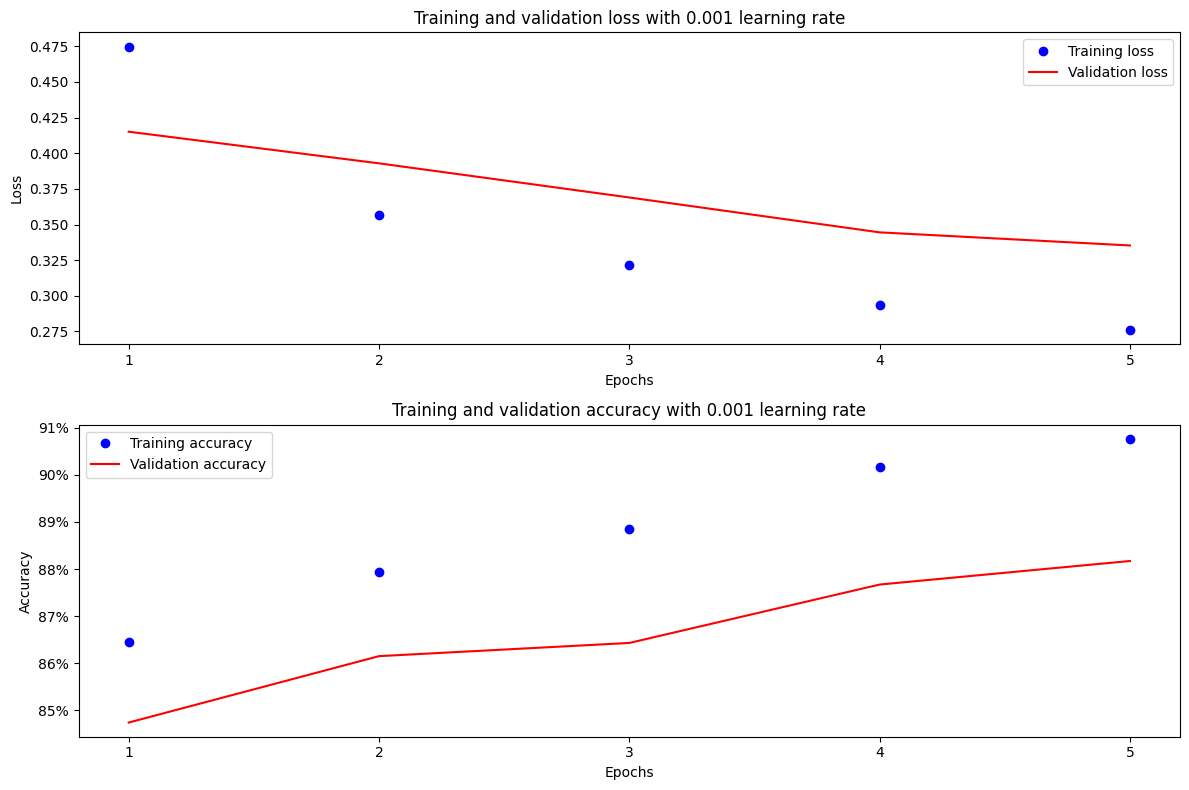

In [9]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chọn CPU hoặc GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu train
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

# Tải dữ liệu validation
val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    val = FMNISTDataset(val_images, val_targets)

    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# Model với Adam lr = 0.001
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(
        model.parameters(),
        lr=1e-3
    )

    return model, loss_fn, optimizer

# Train 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)

    batch_loss = loss_fn(
        prediction,
        y
    )

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Accuracy
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Validation Loss
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)

    loss = loss_fn(
        prediction,
        y
    )

    return loss.item()

# Khởi tạo dữ liệu và mô hình
trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Huấn luyện 5 epoch
for epoch in range(5):

    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train Loss
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(
            x,
            y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(
        train_epoch_losses
    )

    # Train Accuracy
    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(
            x,
            y,
            model
        )

        train_epoch_accuracies.extend(
            is_correct
        )

    train_epoch_accuracy = np.mean(
        train_epoch_accuracies
    )

    # Validation
    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(
            x,
            y,
            model
        )

        validation_loss = val_loss(
            x,
            y,
            model,
            loss_fn
        )

    val_epoch_accuracy = np.mean(
        val_is_correct
    )

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

# Vẽ biểu đồ
epochs = np.arange(5) + 1

plt.figure(figsize=(12,8))

# Loss
plt.subplot(211)

plt.plot(
    epochs,
    train_losses,
    "bo",
    label="Training loss"
)

plt.plot(
    epochs,
    val_losses,
    "r",
    label="Validation loss"
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    "Training and validation loss with 0.001 learning rate"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

# Accuracy
plt.subplot(212)

plt.plot(
    epochs,
    train_accuracies,
    "bo",
    label="Training accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    "r",
    label="Validation accuracy"
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    "Training and validation accuracy with 0.001 learning rate"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.gca().set_yticklabels(
    [
        "{:.0f}%".format(x * 100)
        for x in plt.gca().get_yticks()
    ]
)

plt.legend()

plt.tight_layout()
plt.show()

câu 10

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5


/tmp/ipykernel_12650/3244326568.py:317: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


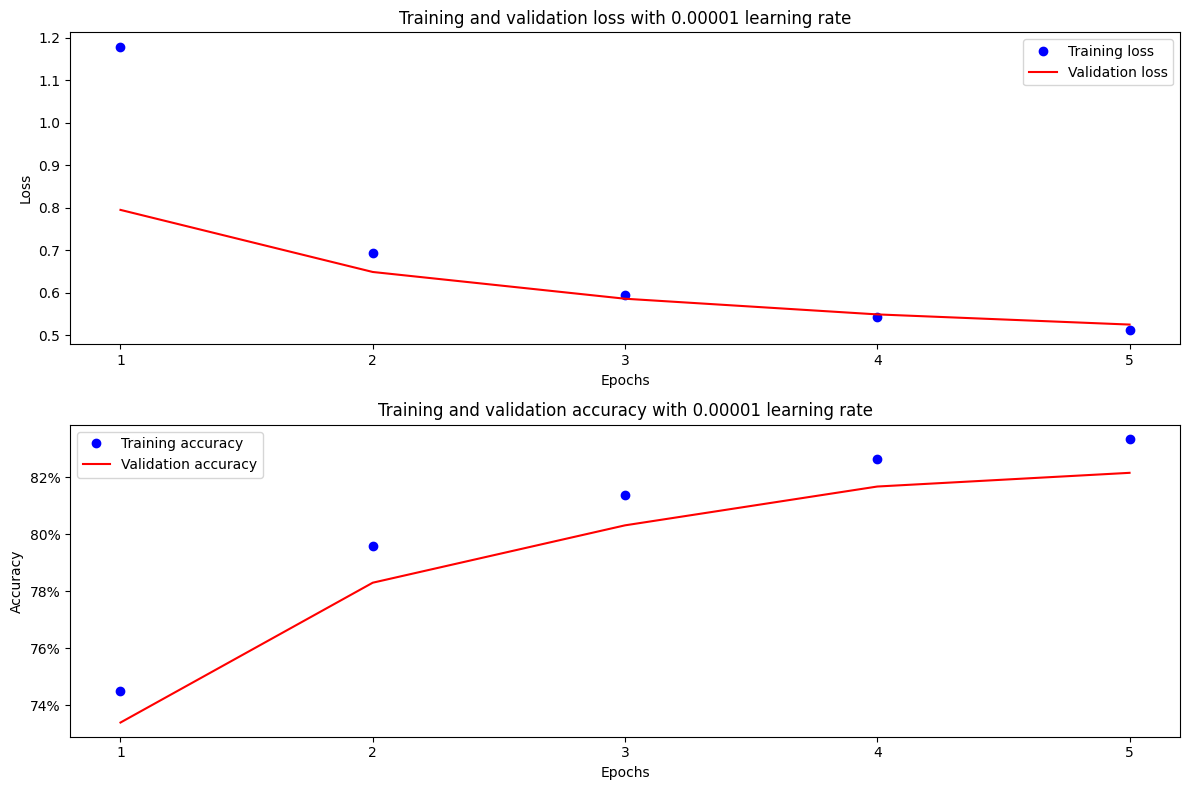

In [10]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================
# LOAD DATA
# =====================

data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    train=True,
    download=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    train=False,
    download=True
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# =====================
# DATASET
# =====================

class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, idx):
        return self.x[idx].to(device), self.y[idx].to(device)

    def __len__(self):
        return len(self.x)

# =====================
# DATALOADER
# =====================

def get_data():

    train = FMNISTDataset(
        tr_images,
        tr_targets
    )

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    val = FMNISTDataset(
        val_images,
        val_targets
    )

    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# =====================
# MODEL
# =====================

def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(
        model.parameters(),
        lr=1e-5
    )

    return model, loss_fn, optimizer

# =====================
# TRAIN BATCH
# =====================

def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(
        prediction,
        y
    )

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# =====================
# ACCURACY
# =====================

@torch.no_grad()
def accuracy(x, y, model):

    model.eval()

    prediction = model(x)

    _, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# =====================
# VALIDATION LOSS
# =====================

@torch.no_grad()
def val_loss(x, y, model, loss_fn):

    model.eval()

    prediction = model(x)

    loss = loss_fn(
        prediction,
        y
    )

    return loss.item()

# =====================
# TRAINING
# =====================

trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(5):

    print(f"Epoch {epoch+1}")

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train Loss
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(
            x,
            y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(
        train_epoch_losses
    )

    # Train Accuracy
    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(
            x,
            y,
            model
        )

        train_epoch_accuracies.extend(
            is_correct
        )

    train_epoch_accuracy = np.mean(
        train_epoch_accuracies
    )

    # Validation
    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(
            x,
            y,
            model
        )

        validation_loss = val_loss(
            x,
            y,
            model,
            loss_fn
        )

    val_epoch_accuracy = np.mean(
        val_is_correct
    )

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

# =====================
# VISUALIZATION
# =====================

epochs = np.arange(5) + 1

plt.figure(figsize=(12,8))

# Loss
plt.subplot(211)

plt.plot(
    epochs,
    train_losses,
    "bo",
    label="Training loss"
)

plt.plot(
    epochs,
    val_losses,
    "r",
    label="Validation loss"
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    "Training and validation loss with 0.00001 learning rate"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

# Accuracy
plt.subplot(212)

plt.plot(
    epochs,
    train_accuracies,
    "bo",
    label="Training accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    "r",
    label="Validation accuracy"
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    "Training and validation accuracy with 0.00001 learning rate"
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.gca().set_yticklabels(
    [
        "{:.0f}%".format(x * 100)
        for x in plt.gca().get_yticks()
    ]
)

plt.legend()

plt.tight_layout()
plt.show()

câu 11

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_12650/3520920478.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


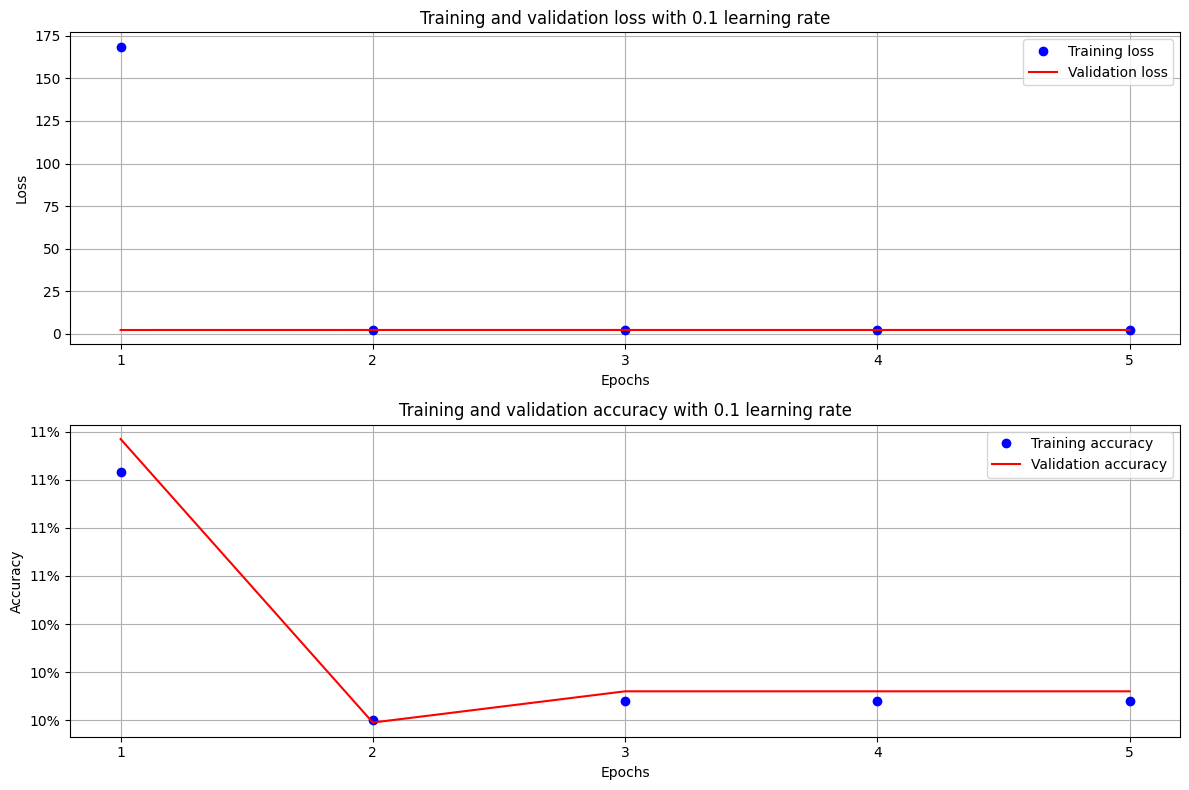

In [11]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chọn CPU hoặc GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# Dataset KHÔNG chia 255
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    val = FMNISTDataset(val_images, val_targets)

    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# Model với Adam learning rate = 0.1
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(
        model.parameters(),
        lr=1e-1
    )

    return model, loss_fn, optimizer

# Huấn luyện 1 batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Tính độ chính xác
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Validation loss
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()

# Khởi tạo
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Huấn luyện 5 epoch
for epoch in range(5):
    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train loss
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        batch_loss = train_batch(
            x,
            y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    # Train accuracy
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch

        is_correct = accuracy(
            x,
            y,
            model
        )

        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Validation
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch

        val_is_correct = accuracy(
            x,
            y,
            model
        )

        validation_loss = val_loss(
            x,
            y,
            model,
            loss_fn
        )

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

# Vẽ biểu đồ
epochs = np.arange(5) + 1

plt.figure(figsize=(12, 8))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss with 0.1 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid("off")

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 0.1 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(
    ["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()]
)
plt.legend()
plt.grid("off")

plt.tight_layout()
plt.show()

câu 12

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_12650/1637860161.py:297: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


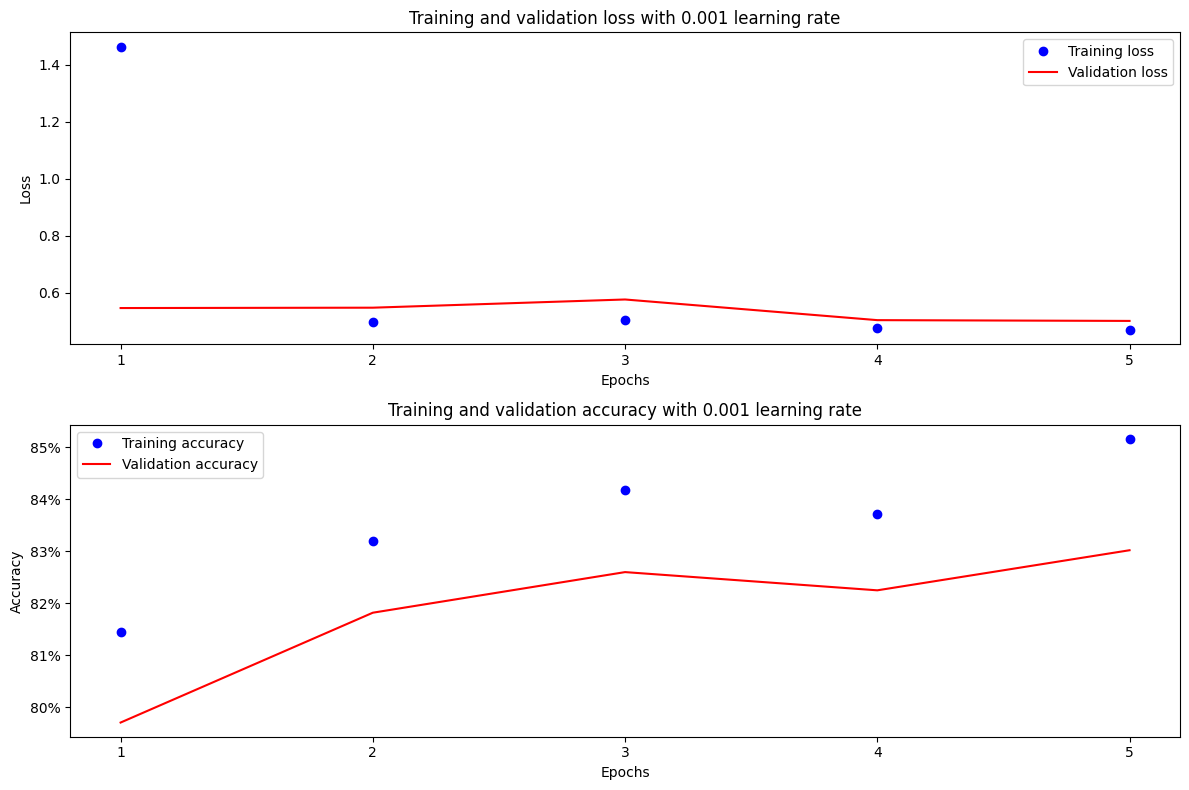

In [12]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chọn thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"

# Tải dữ liệu train
data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

# Tải dữ liệu validation
val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# Dataset (KHÔNG CHIA 255)
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    val = FMNISTDataset(val_images, val_targets)

    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# Model với Adam lr=0.001
def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(
        model.parameters(),
        lr=1e-3
    )

    return model, loss_fn, optimizer

# Train một batch
def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(
        prediction,
        y
    )

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Accuracy
@torch.no_grad()
def accuracy(x, y, model):

    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# Validation Loss
@torch.no_grad()
def val_loss(x, y, model, loss_fn):

    model.eval()

    prediction = model(x)

    validation_loss = loss_fn(
        prediction,
        y
    )

    return validation_loss.item()

# Khởi tạo dữ liệu và mô hình
trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

# Huấn luyện
for epoch in range(5):

    print("Epoch:", epoch + 1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Training Loss
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(
            x,
            y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(
        train_epoch_losses
    ).mean()

    # Training Accuracy
    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(
            x,
            y,
            model
        )

        train_epoch_accuracies.extend(
            is_correct
        )

    train_epoch_accuracy = np.mean(
        train_epoch_accuracies
    )

    # Validation
    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(
            x,
            y,
            model
        )

        validation_loss = val_loss(
            x,
            y,
            model,
            loss_fn
        )

    val_epoch_accuracy = np.mean(
        val_is_correct
    )

    train_losses.append(
        train_epoch_loss
    )

    train_accuracies.append(
        train_epoch_accuracy
    )

    val_losses.append(
        validation_loss
    )

    val_accuracies.append(
        val_epoch_accuracy
    )

# Vẽ biểu đồ
epochs = np.arange(5) + 1

plt.figure(figsize=(12,8))

# Loss
plt.subplot(211)

plt.plot(
    epochs,
    train_losses,
    'bo',
    label='Training loss'
)

plt.plot(
    epochs,
    val_losses,
    'r',
    label='Validation loss'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation loss with 0.001 learning rate'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

# Accuracy
plt.subplot(212)

plt.plot(
    epochs,
    train_accuracies,
    'bo',
    label='Training accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    'r',
    label='Validation accuracy'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation accuracy with 0.001 learning rate'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    [
        '{:.0f}%'.format(x * 100)
        for x in plt.gca().get_yticks()
    ]
)

plt.legend()

plt.grid(False)

plt.tight_layout()
plt.show()

câu 13

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5


/tmp/ipykernel_12650/1693514692.py:330: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


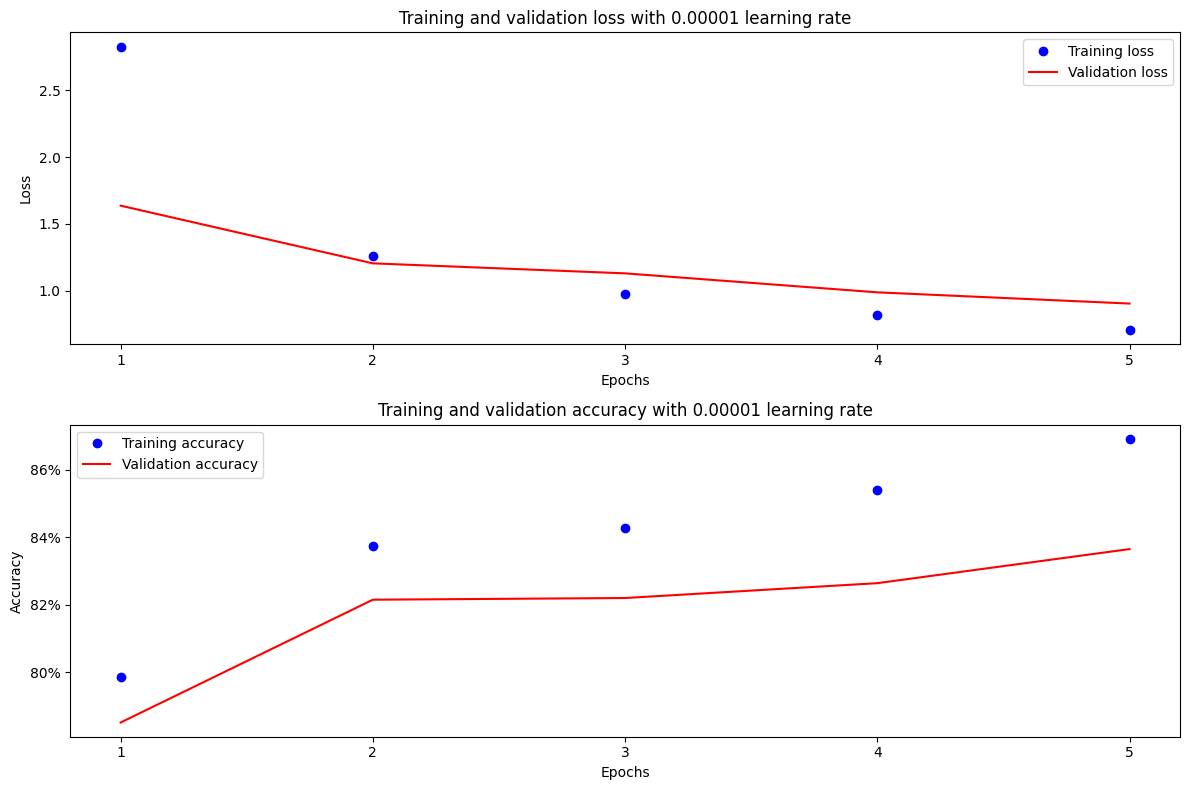

In [13]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# LOAD DATA
# =========================

data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    train=True,
    download=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    train=False,
    download=True
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets

# =========================
# DATASET
# KHÔNG CHIA 255
# =========================

class FMNISTDataset(Dataset):

    def __init__(self, x, y):

        x = x.float()
        x = x.view(-1, 28 * 28)

        self.x = x
        self.y = y

    def __getitem__(self, idx):
        return self.x[idx].to(device), self.y[idx].to(device)

    def __len__(self):
        return len(self.x)

# =========================
# DATALOADER
# =========================

def get_data():

    train = FMNISTDataset(
        tr_images,
        tr_targets
    )

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    val = FMNISTDataset(
        val_images,
        val_targets
    )

    val_dl = DataLoader(
        val,
        batch_size=len(val_images),
        shuffle=False
    )

    return trn_dl, val_dl

# =========================
# MODEL
# LR = 0.00001
# =========================

def get_model():

    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = Adam(
        model.parameters(),
        lr=1e-5
    )

    return model, loss_fn, optimizer

# =========================
# TRAIN BATCH
# =========================

def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(
        prediction,
        y
    )

    batch_loss.backward()

    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# =========================
# ACCURACY
# =========================

@torch.no_grad()
def accuracy(x, y, model):

    model.eval()

    prediction = model(x)

    _, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

# =========================
# VALIDATION LOSS
# =========================

@torch.no_grad()
def val_loss(x, y, model, loss_fn):

    model.eval()

    prediction = model(x)

    loss = loss_fn(
        prediction,
        y
    )

    return loss.item()

# =========================
# TRAINING
# =========================

trn_dl, val_dl = get_data()

model, loss_fn, optimizer = get_model()

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(5):

    print(f"Epoch {epoch+1}")

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Training Loss
    for batch in trn_dl:

        x, y = batch

        batch_loss = train_batch(
            x,
            y,
            model,
            optimizer,
            loss_fn
        )

        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(
        train_epoch_losses
    )

    # Training Accuracy
    for batch in trn_dl:

        x, y = batch

        is_correct = accuracy(
            x,
            y,
            model
        )

        train_epoch_accuracies.extend(
            is_correct
        )

    train_epoch_accuracy = np.mean(
        train_epoch_accuracies
    )

    # Validation
    for batch in val_dl:

        x, y = batch

        val_is_correct = accuracy(
            x,
            y,
            model
        )

        validation_loss = val_loss(
            x,
            y,
            model,
            loss_fn
        )

    val_epoch_accuracy = np.mean(
        val_is_correct
    )

    train_losses.append(
        train_epoch_loss
    )

    train_accuracies.append(
        train_epoch_accuracy
    )

    val_losses.append(
        validation_loss
    )

    val_accuracies.append(
        val_epoch_accuracy
    )

# =========================
# VẼ BIỂU ĐỒ
# =========================

epochs = np.arange(5) + 1

plt.figure(figsize=(12,8))

# LOSS
plt.subplot(211)

plt.plot(
    epochs,
    train_losses,
    'bo',
    label='Training loss'
)

plt.plot(
    epochs,
    val_losses,
    'r',
    label='Validation loss'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation loss with 0.00001 learning rate'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

# ACCURACY
plt.subplot(212)

plt.plot(
    epochs,
    train_accuracies,
    'bo',
    label='Training accuracy'
)

plt.plot(
    epochs,
    val_accuracies,
    'r',
    label='Validation accuracy'
)

plt.gca().xaxis.set_major_locator(
    mticker.MultipleLocator(1)
)

plt.title(
    'Training and validation accuracy with 0.00001 learning rate'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(
    [
        '{:.0f}%'.format(x * 100)
        for x in plt.gca().get_yticks()
    ]
)

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()